**1.clone repo(colab only)**




In [1]:
!git clone https://github.com/MohamedAAbdullah1/NTI-Final-Project.git
%cd NTI-Final-Project

Cloning into 'NTI-Final-Project'...
remote: Enumerating objects: 82, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 82 (delta 31), reused 43 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (82/82), 3.12 MiB | 8.14 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/NTI-Final-Project


**2.imports**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
%matplotlib inline

**3.load Data**

In [3]:
X_train = pd.read_csv("data/processed/X_train.csv")
X_test = pd.read_csv("data/processed/X_test.csv")
y_train = pd.read_csv("data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("data/processed/y_test.csv").values.ravel()

**4.Build pipeline(encode categoricals +Random Forest+Train)**

In [4]:
categorical_cols = ["Locality", "Network Type"]
numeric_cols = ["Latitude", "Longitude", "Signal Strength (dBm)", "Latency (ms)"]

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_pipeline = grid.best_estimator_

Best params: {'model__max_depth': 10, 'model__n_estimators': 100}


**6.Evaluate**

In [5]:
y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)

print("=== Random Forest Model Performance ===")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")
print(f"\nBaseline MAE: {mean_absolute_error(y_test, y_dummy):.4f}")

=== Random Forest Model Performance ===
MAE  : 6.4638
MSE  : 177.9048
RMSE : 13.3381
R2   : 0.7355

Baseline MAE: 19.2824


**7.Feature Importance**

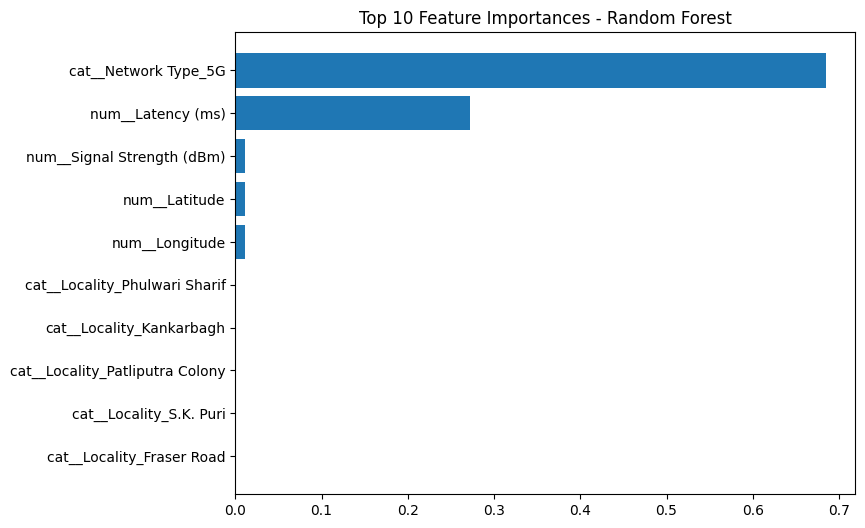

In [7]:
importances = best_pipeline.named_steps["model"].feature_importances_
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(importance_df["feature"][:10], importance_df["importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

**8.Save model**

In [8]:
models_dir = 'models'
os.makedirs(models_dir, exist_ok=True)
joblib.dump(best_pipeline, os.path.join(models_dir, 'rf_pipeline.pkl'))

['models/rf_pipeline.pkl']